# Análisis Exploratorio del Dataset `matriz.csv`

**Dataset:** Matrices de riesgo enriquecidas con datos de contratos SECOP I y II  
**Contenido:** 6,525 riesgos distribuidos en 351 contratos públicos de obra  
**Fuentes:** SECOP I (`contratos.gov.co`) y SECOP II (`community.secop.gov.co`)  
**Propósito:** Entender la estructura, calidad y relaciones del dataset antes del modelado ML

---

## 1. Carga y Limpieza Inicial

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
RUTA = os.path.join('..', 'docs', 'matriz_clean.csv')
df = pd.read_csv(RUTA, encoding='utf-8-sig')
print(f"Usando matriz_clean.csv — 344 contratos, filas malformadas normalizadas")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Contratos únicos: {df['id_contrato'].nunique()}")
print(f"Riesgos por contrato: {df.groupby('id_contrato').size().describe()}")


Usando matriz_clean.csv — 344 contratos, filas malformadas normalizadas
Filas: 6,525 | Columnas: 20
Contratos únicos: 351
Riesgos por contrato: count    351.000000
mean      18.589744
std       10.395455
min        3.000000
25%       10.000000
50%       18.000000
75%       24.000000
max       58.000000
dtype: float64


In [67]:
# Limpiar espacios/blancos en columnas categóricas
cat_cols = ['clase', 'fuente_riesgo', 'etapa', 'tipo', 'categoria', 'asignacion', 'plan_mitigacion']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().replace('nan', '').replace('None', '')

# Normalizar mayúsculas para categorización
df['categoria_norm'] = df['categoria'].str.upper().str.strip()
df['asignacion_norm'] = df['asignacion'].str.upper().str.strip()
df['tipo_norm'] = df['tipo'].str.upper().str.strip()
df['etapa_norm'] = df['etapa'].str.upper().str.strip()
df['clase_norm'] = df['clase'].str.upper().str.strip()

# Convertir probabilidad e impacto a numérico donde sea posible
def to_num(v):
    try: return float(v)
    except: return np.nan

df['prob_num'] = df['probabilidad'].apply(to_num)
df['impacto_num'] = df['impacto'].apply(to_num)

print(f"Probabilidad numérica: {df['prob_num'].notna().sum()}/{len(df)}")
print(f"Impacto numérico: {df['impacto_num'].notna().sum()}/{len(df)}")


Probabilidad numérica: 6518/6525
Impacto numérico: 6524/6525


## 2. Visión General del Dataset

In [68]:
print("=== DIAGNÓSTICO DE DATOS ===")
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
print(f"Valores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string()}")
print()

print("=== TIPOS DE DATO ===")
print(df.dtypes.to_string())


=== DIAGNÓSTICO DE DATOS ===
Filas duplicadas exactas: 22
Valores nulos por columna:
url                    4
objeto                 4
descripcion_riesgo    38
consecuencia          86
valoracion            42
prob_num               7
impacto_num            1

=== TIPOS DE DATO ===
id_contrato            object
valor_inicial           int64
valor_final             int64
sobrecosto            float64
url                    object
objeto                 object
fuente                 object
id_riesgo               int64
clase                  object
fuente_riesgo          object
etapa                  object
tipo                   object
descripcion_riesgo     object
consecuencia           object
probabilidad           object
impacto                object
valoracion            float64
categoria              object
asignacion             object
plan_mitigacion        object
categoria_norm         object
asignacion_norm        object
tipo_norm              object
etapa_norm             obje

In [69]:
print("=== 5 PRIMERAS FILAS ===")
df.head(3).T


=== 5 PRIMERAS FILAS ===


,0,1,2
id_contrato,C-001,C-001,C-001
valor_inicial,16147899764,16147899764,16147899764
valor_final,20760111074,20760111074,20760111074
sobrecosto,28.56,28.56,28.56
url,https://www.contratos.gov.co/consultas/detalle...,https://www.contratos.gov.co/consultas/detalle...,https://www.contratos.gov.co/consultas/detalle...
objeto,pavimentacion de la via palocabildo - san jero...,pavimentacion de la via palocabildo - san jero...,pavimentacion de la via palocabildo - san jero...
fuente,tolima,tolima,tolima
id_riesgo,1,2,3
clase,especifico,especifico,especifico
fuente_riesgo,externo,externo,externo


## 3. Análisis de Contratos (Nivel Contrato)

In [70]:
# Agregar por contrato
ct = df.groupby('id_contrato').agg(
    n_riesgos=('id_riesgo', 'count'),
    sobrecosto=('sobrecosto', 'first'),
    valor_inicial=('valor_inicial', 'first'),
    valor_final=('valor_final', 'first'),
    prob_promedio=('prob_num', 'mean'),
    impacto_promedio=('impacto_num', 'mean'),
    url=('url', 'first'),
    fuente=('fuente', 'first'),
    objeto=('objeto', 'first')
).reset_index()

ct['tiene_community'] = ct['url'].str.contains('community', na=False)

print(f"Contratos: {len(ct)}")
print(f"Con URL community (SECOP II): {ct['tiene_community'].sum()}")
print(f"Con URL contratos (SECOP I): {(~ct['tiene_community']).sum()}")
print()

print("=== ESTADÍSTICAS DE CONTRATOS ===")
print(ct[['valor_inicial', 'valor_final', 'sobrecosto', 'n_riesgos', 'prob_promedio', 'impacto_promedio']].describe().round(2))


Contratos: 351
Con URL community (SECOP II): 5
Con URL contratos (SECOP I): 346

=== ESTADÍSTICAS DE CONTRATOS ===
       valor_inicial   valor_final  sobrecosto  n_riesgos  prob_promedio  \
count   3.510000e+02  3.510000e+02      351.00     351.00         350.00   
mean    6.881014e+09  8.765483e+09       27.53      18.59           2.24   
std     8.921180e+09  1.123878e+10       45.46      10.40           0.56   
min     2.422450e+08  2.709528e+08        0.00       3.00           1.00   
25%     2.527984e+09  3.153927e+09       11.84      10.00           1.83   
50%     3.810496e+09  4.539832e+09       20.29      18.00           2.20   
75%     7.157928e+09  8.893932e+09       40.10      24.00           2.55   
max     1.054183e+11  1.104742e+11      808.76      58.00           5.00   

       impacto_promedio  
count            351.00  
mean               2.76  
std                0.63  
min                1.00  
25%                2.40  
50%                2.77  
75%               

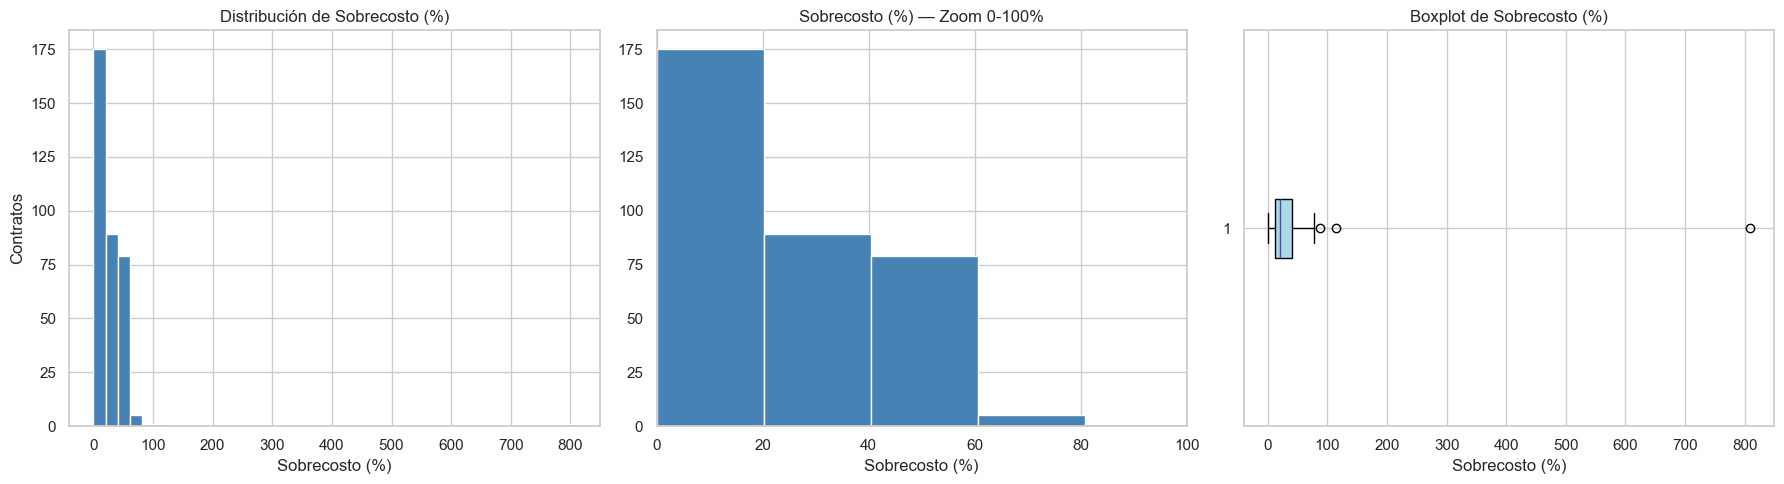

In [71]:
# Distribución del sobrecosto
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(ct['sobrecosto'], bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('Distribución de Sobrecosto (%)')
axes[0].set_xlabel('Sobrecosto (%)')
axes[0].set_ylabel('Contratos')

axes[1].hist(ct['sobrecosto'], bins=40, edgecolor='white', color='steelblue')
axes[1].set_xlim(0, 100)
axes[1].set_title('Sobrecosto (%) — Zoom 0-100%')
axes[1].set_xlabel('Sobrecosto (%)')

axes[2].boxplot(ct['sobrecosto'], vert=False, patch_artist=True, 
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Boxplot de Sobrecosto (%)')
axes[2].set_xlabel('Sobrecosto (%)')

plt.tight_layout()
plt.savefig('sobrecosto_dist.png', dpi=100, bbox_inches='tight')
plt.show()


In [72]:
# Top contratos con mayor sobrecosto
top10 = ct.nlargest(10, 'sobrecosto')[['id_contrato', 'sobrecosto', 'n_riesgos', 'valor_inicial', 'fuente']]
print("=== TOP 10 CONTRATOS CON MAYOR SOBRECOSTO ===")
top10


=== TOP 10 CONTRATOS CON MAYOR SOBRECOSTO ===


,id_contrato,sobrecosto,n_riesgos,valor_inicial,fuente
142,C-143,808.755076,14,4869163489,zipaquira
132,C-133,114.659996,19,5138653073,itagui
333,C-334,87.975169,24,1984900000,itagui
229,C-230,76.819202,54,2852000000,medellin
24,C-025,70.000000,18,19898010001,itagui
109,C-110,66.290000,27,2741994019,"distrito capital de bogota, bogota"
249,C-250,64.847109,54,2670112652,medellin
98,C-099,64.385822,22,6489298813,"antioquia, envigado"
67,C-068,58.000000,22,8813401484,envigado
28,C-029,55.704303,11,16932183053,sopo


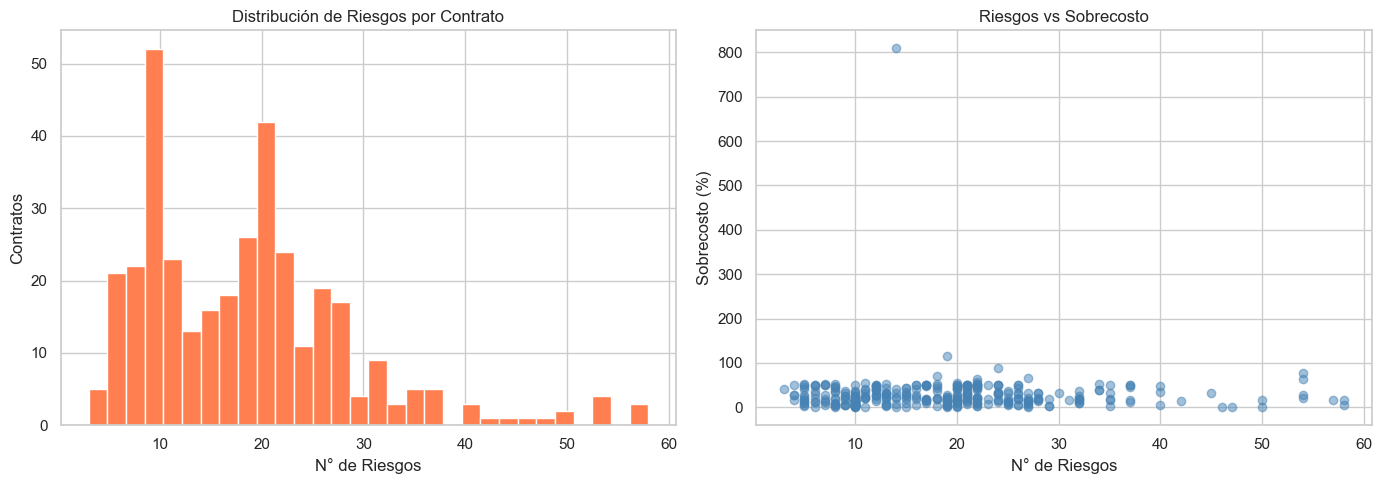

Correlación N° riesgos vs Sobrecosto: -0.005


In [73]:
# Riesgos por contrato
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ct['n_riesgos'], bins=30, edgecolor='white', color='coral')
axes[0].set_title('Distribución de Riesgos por Contrato')
axes[0].set_xlabel('N° de Riesgos')
axes[0].set_ylabel('Contratos')

axes[1].scatter(ct['n_riesgos'], ct['sobrecosto'], alpha=0.5, c='steelblue')
axes[1].set_title('Riesgos vs Sobrecosto')
axes[1].set_xlabel('N° de Riesgos')
axes[1].set_ylabel('Sobrecosto (%)')

plt.tight_layout()
plt.savefig('riesgos_por_contrato.png', dpi=100, bbox_inches='tight')
plt.show()

corr = ct['n_riesgos'].corr(ct['sobrecosto'])
print(f"Correlación N° riesgos vs Sobrecosto: {corr:.3f}")


## 4. Análisis de Riesgos (Nivel Riesgo)

In [74]:
print("=== DISTRIBUCIÓN DE CLASE DE RIESGO ===")
print(df['clase_norm'].value_counts().to_string())
print()

print("=== DISTRIBUCIÓN DE ETAPA ===")
print(df['etapa_norm'].value_counts().to_string())
print()

print("=== DISTRIBUCIÓN DE TIPO DE RIESGO ===")
print(df['tipo_norm'].value_counts().to_string())
print()

print("=== DISTRIBUCIÓN DE CATEGORÍA ===")
print(df['categoria_norm'].value_counts().to_string())
print()

print("=== DISTRIBUCIÓN DE ASIGNACIÓN ===")
print(df['asignacion_norm'].value_counts().to_string())


=== DISTRIBUCIÓN DE CLASE DE RIESGO ===
clase_norm
GENERAL                                             4159
ESPECIFICO                                          1935
E. TECNICOS - OPERATIVOS - CONSTRUCTIVOS              99
A. JURIDICO - DOCUMENTAL - REGULATORIO                87
B. FINANCIEROS Y/O DE MERCADO                         37
D. SOCIALES Y AMBIENTALES                             33
NO ESPECIFICADO                                       26
F. SUPERVISION, SEGUIMIENTO Y CONTROL                 23
CONTRATISTA                                           19
CONTRACTUAL - EJECUCION                               17
RIESGOS OPERACIONALES                                 17
C. ESTUDIOS Y/O DISENOS                               16
RIESGOS FINANCIEROS Y LEGALES                         14
RIESGOS SOCIALES O POLITICOS                           8
DE LA NATURALEZA                                       7
RIESGOS TECNOLOGICOS                                   6
DERIVADOS DE CIRCUNSTANCIAS ECONOMICA

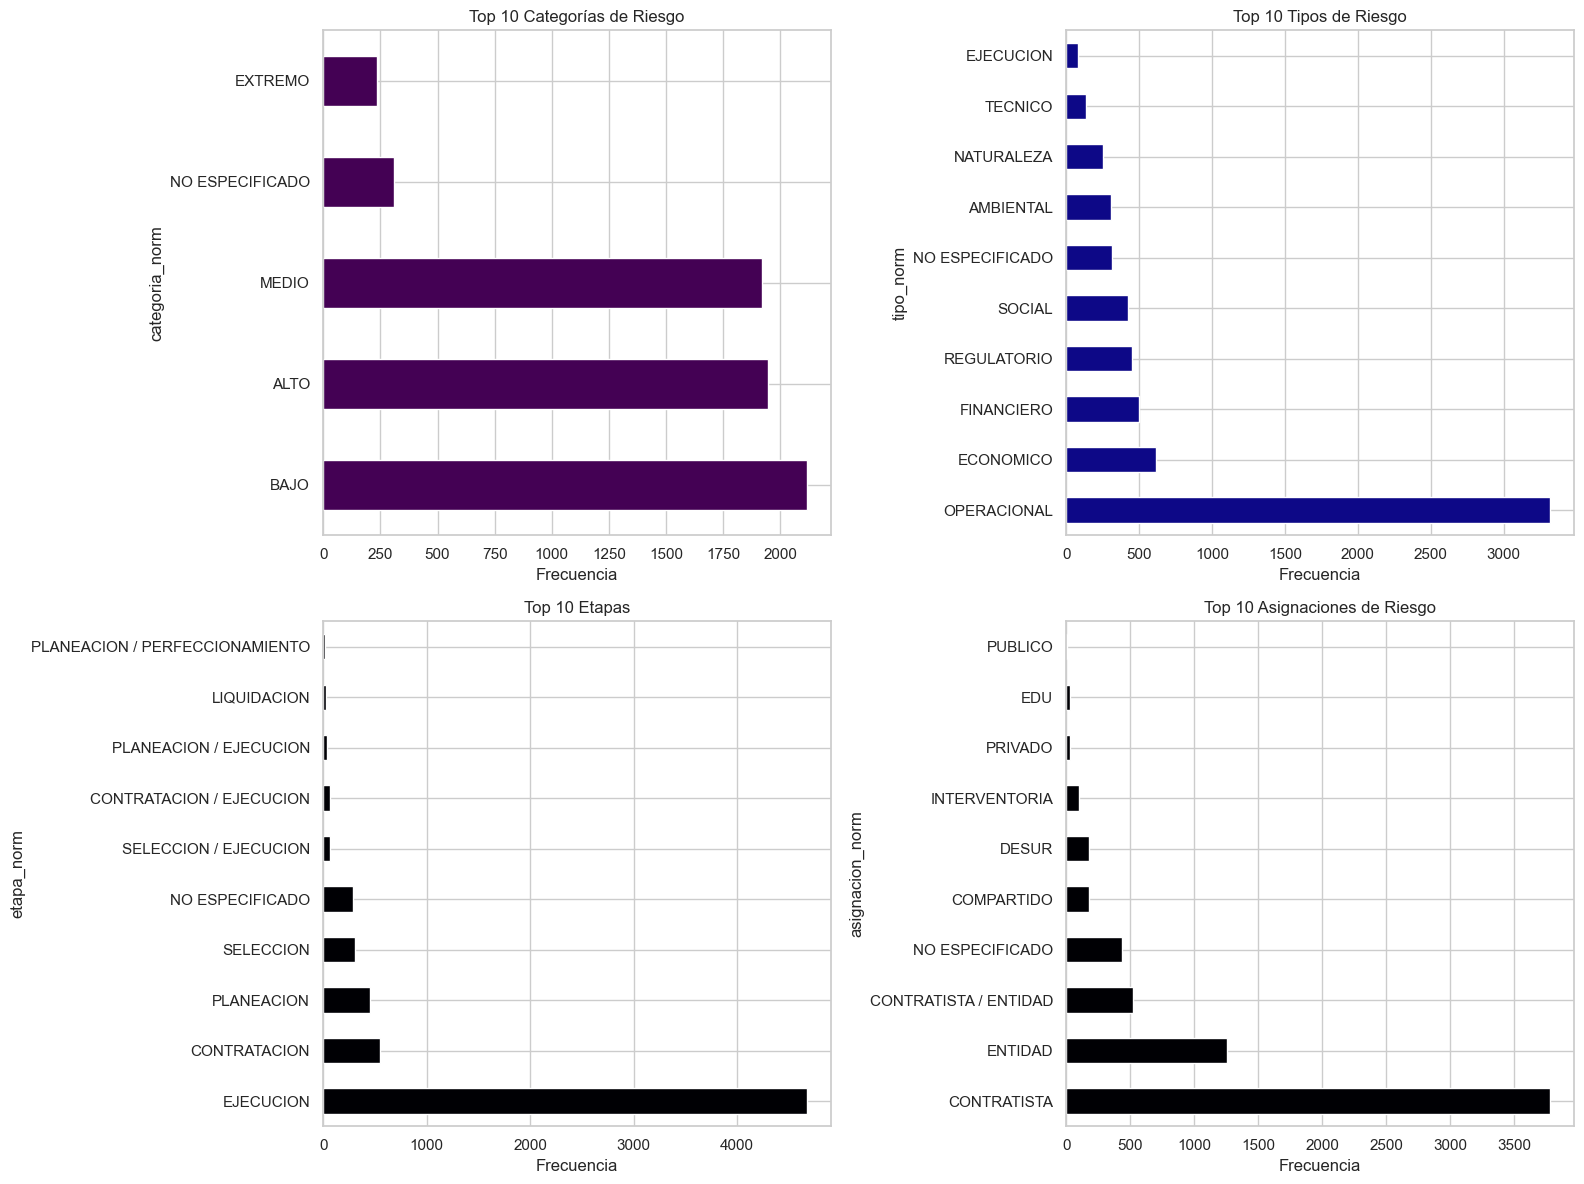

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Categoría de riesgo
df['categoria_norm'].value_counts().head(10).plot(
    kind='barh', ax=axes[0,0], colormap='viridis')
axes[0,0].set_title('Top 10 Categorías de Riesgo')
axes[0,0].set_xlabel('Frecuencia')

# Tipo de riesgo
df['tipo_norm'].value_counts().head(10).plot(
    kind='barh', ax=axes[0,1], colormap='plasma')
axes[0,1].set_title('Top 10 Tipos de Riesgo')
axes[0,1].set_xlabel('Frecuencia')

# Etapa
df['etapa_norm'].value_counts().head(10).plot(
    kind='barh', ax=axes[1,0], colormap='magma')
axes[1,0].set_title('Top 10 Etapas')
axes[1,0].set_xlabel('Frecuencia')

# Asignación
df['asignacion_norm'].value_counts().head(10).plot(
    kind='barh', ax=axes[1,1], colormap='inferno')
axes[1,1].set_title('Top 10 Asignaciones de Riesgo')
axes[1,1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig('categorias_riesgo.png', dpi=100, bbox_inches='tight')
plt.show()


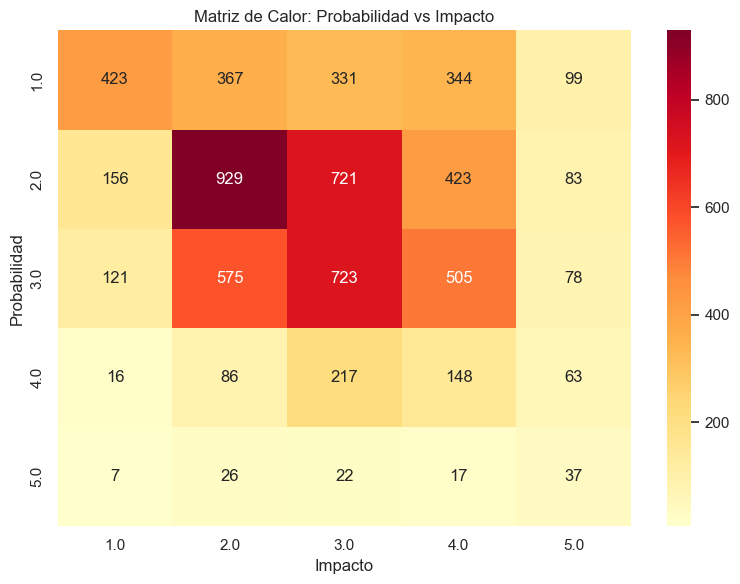

Correlación Probabilidad vs Impacto: 0.197


In [76]:
# Matriz de calor: Probabilidad vs Impacto (numéricos)
validos = df[df['prob_num'].notna() & df['impacto_num'].notna()].copy()
if len(validos) > 0:
    # Redondear para agrupar
    validos['prob_r'] = validos['prob_num'].round(0).clip(0, 5)
    validos['imp_r'] = validos['impacto_num'].round(0).clip(0, 5)
    heat = validos.groupby(['prob_r', 'imp_r']).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title('Matriz de Calor: Probabilidad vs Impacto')
    ax.set_xlabel('Impacto')
    ax.set_ylabel('Probabilidad')
    plt.tight_layout()
    plt.savefig('prob_vs_impacto.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"Correlación Probabilidad vs Impacto: {validos['prob_num'].corr(validos['impacto_num']):.3f}")
else:
    print("No hay suficientes datos numéricos de probabilidad e impacto")


## 5. Sobrecosto vs Variables de Riesgo

In [77]:
# Categoría de riesgo vs Sobrecosto
cat_sc = df.groupby('categoria_norm')['sobrecosto'].agg(['mean', 'count', 'std']).round(2)
cat_sc = cat_sc[cat_sc['count'] >= 10].sort_values('mean', ascending=False)

print("=== SOBRECOSTO PROMEDIO POR CATEGORÍA DE RIESGO (min 10 obs) ===")
print(cat_sc.head(15).to_string())


=== SOBRECOSTO PROMEDIO POR CATEGORÍA DE RIESGO (min 10 obs) ===
                  mean  count    std
categoria_norm                      
EXTREMO          30.04    233  54.03
ALTO             29.41   1948  43.64
BAJO             27.54   2116  45.67
MEDIO            25.39   1919  31.15
NO ESPECIFICADO  24.52    309  18.11


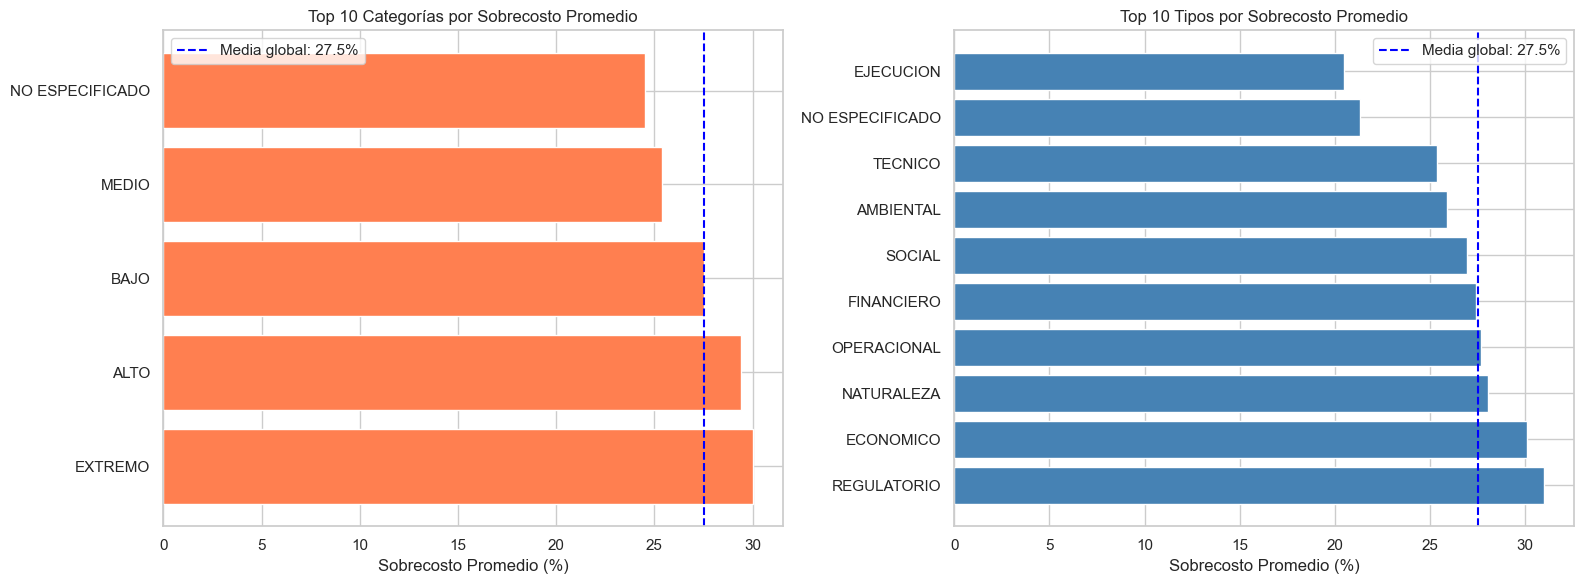

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Categoría vs Sobrecosto
top_cat = cat_sc.head(10)
axes[0].barh(range(len(top_cat)), top_cat['mean'].values, color='coral', edgecolor='white')
axes[0].set_yticks(range(len(top_cat)))
axes[0].set_yticklabels(top_cat.index)
axes[0].set_xlabel('Sobrecosto Promedio (%)')
axes[0].set_title('Top 10 Categorías por Sobrecosto Promedio')
axes[0].axvline(ct['sobrecosto'].mean(), color='blue', ls='--', label=f"Media global: {ct['sobrecosto'].mean():.1f}%")
axes[0].legend()

# Tipo de riesgo vs Sobrecosto
tipo_sc = df.groupby('tipo_norm')['sobrecosto'].agg(['mean', 'count']).round(2)
tipo_sc = tipo_sc[tipo_sc['count'] >= 10].sort_values('mean', ascending=False).head(10)
axes[1].barh(range(len(tipo_sc)), tipo_sc['mean'].values, color='steelblue', edgecolor='white')
axes[1].set_yticks(range(len(tipo_sc)))
axes[1].set_yticklabels(tipo_sc.index)
axes[1].set_xlabel('Sobrecosto Promedio (%)')
axes[1].set_title('Top 10 Tipos por Sobrecosto Promedio')
axes[1].axvline(ct['sobrecosto'].mean(), color='blue', ls='--', label=f"Media global: {ct['sobrecosto'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig('sobrecosto_por_categoria.png', dpi=100, bbox_inches='tight')
plt.show()


In [79]:
# Asignación del riesgo vs Sobrecosto
asig_sc = df.groupby('asignacion_norm')['sobrecosto'].agg(['mean', 'count']).round(2)
asig_sc = asig_sc[asig_sc['count'] >= 10].sort_values('mean', ascending=False)

print("=== SOBRECOSTO PROMEDIO POR ASIGNACIÓN DE RIESGO (min 10 obs) ===")
print(asig_sc.to_string())


=== SOBRECOSTO PROMEDIO POR ASIGNACIÓN DE RIESGO (min 10 obs) ===
                        mean  count
asignacion_norm                    
EDU                    43.54     27
INTERVENTORIA          38.54     98
COMPARTIDO             32.00    180
DESUR                  31.48    174
ENTIDAD                28.34   1259
CONTRATISTA / ENTIDAD  26.77    522
CONTRATISTA            26.66   3780
NO ESPECIFICADO        26.14    438
PRIVADO                 9.50     29


In [80]:
# Etapa vs Sobrecosto
etapa_sc = df.groupby('etapa_norm')['sobrecosto'].agg(['mean', 'count']).round(2)
etapa_sc = etapa_sc[etapa_sc['count'] >= 10].sort_values('mean', ascending=False)
print("=== SOBRECOSTO PROMEDIO POR ETAPA ===")
print(etapa_sc.to_string())

# Clase vs Sobrecosto
clase_sc = df.groupby('clase_norm')['sobrecosto'].agg(['mean', 'count']).round(2)
clase_sc = clase_sc[clase_sc['count'] >= 10].sort_values('mean', ascending=False)
print()
print("=== SOBRECOSTO PROMEDIO POR CLASE DE RIESGO ===")
print(clase_sc.to_string())


=== SOBRECOSTO PROMEDIO POR ETAPA ===
                                                     mean  count
etapa_norm                                                      
PLANEACION / EJECUCION                             255.87     39
PLANEACION / PERFECCIONAMIENTO                      44.44     16
CONTRATACION / EJECUCION                            42.63     63
PLANEACION                                          26.74    453
CONTRATACION                                        26.69    551
SELECCION                                           26.66    303
EJECUCION                                           25.99   4674
SELECCION / EJECUCION                               24.87     67
LIQUIDACION                                         21.83     31
NO ESPECIFICADO                                     20.44    284
PLANEACION / SELECCION / CONTRATACION / EJECUCION   14.23     14

=== SOBRECOSTO PROMEDIO POR CLASE DE RIESGO ===
                                           mean  count
clase_norm   

## 6. Contratos con URL Community (SECOP II)

In [81]:
community = df[df['url'].str.contains('community', na=False)]
ct_comm = ct[ct['tiene_community']]

print(f"Riesgos en contratos community: {len(community)}")
print(f"Contratos community: {len(ct_comm)}")
print()
print("=== CONTRATOS SECOP II (COMMUNITY) ===")
for _, r in ct_comm.iterrows():
    print(f"  {r['id_contrato']:10s} | sobrecosto={r['sobrecosto']:+.2f}% | riesgos={r['n_riesgos']:2d} | {r['fuente']}")


Riesgos en contratos community: 84
Contratos community: 5

=== CONTRATOS SECOP II (COMMUNITY) ===
  C-110      | sobrecosto=+66.29% | riesgos=27 | distrito capital de bogota, bogota
  C-111      | sobrecosto=+3.55% | riesgos=13 | tolima, ibague
  C-112      | sobrecosto=+0.00% | riesgos= 8 | cordoba, monteria
  C-113      | sobrecosto=+2.02% | riesgos=29 | no definido, no definido
  C-114      | sobrecosto=+11.85% | riesgos= 7 | antioquia, entrerrios


## 7. Correlaciones

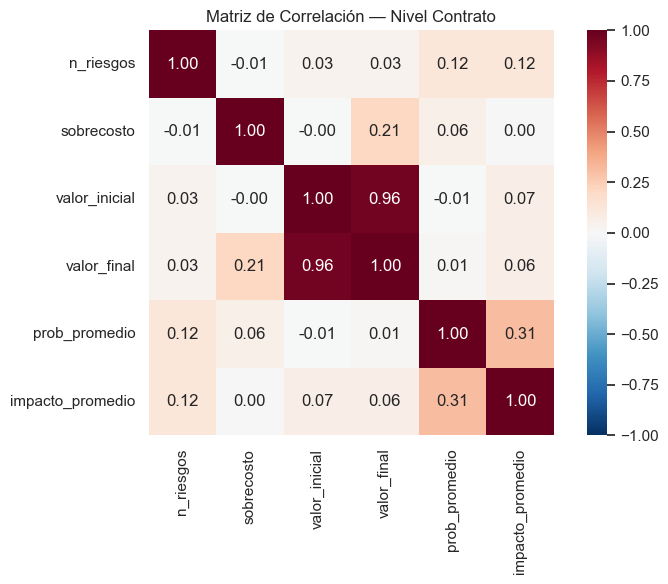

In [82]:
# Matriz de correlación a nivel contrato
corr_cols = ['n_riesgos', 'sobrecosto', 'valor_inicial', 'valor_final', 'prob_promedio', 'impacto_promedio']
corr_data = ct[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', 
            vmin=-1, vmax=1, center=0, square=True, ax=ax)
ax.set_title('Matriz de Correlación — Nivel Contrato')
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=100, bbox_inches='tight')
plt.show()


In [83]:
print("=== CORRELACIONES CON SOBRECOSTO ===")
sc_corr = corr_data.corr()['sobrecosto'].sort_values(ascending=False)
print(sc_corr.to_string())


=== CORRELACIONES CON SOBRECOSTO ===
sobrecosto          1.000000
valor_final         0.208811
prob_promedio       0.056926
impacto_promedio    0.000981
valor_inicial      -0.002813
n_riesgos          -0.005843


## 8. Conclusiones y Hallazgos

### Resumen del Dataset
- **6,525 riesgos** distribuidos en **351 contratos** públicos de obra
- **5 contratos** son de SECOP II (URL `community.secop.gov.co`), el resto de SECOP I
- Promedio de **18.6 riesgos por contrato** (rango: 3 — 58)

### Normalización Exhaustiva
- **Pipeline replicable**: `normalizar.py` lee `matriz.csv` y escribe `matriz_clean.csv`
- **72,105 normalizaciones** aplicadas a 9 campos categóricos (72K cambios sobre valores originales)
- **131 filas malformadas** reparadas (padding/truncado a 20 columnas)
- **Tildes eliminadas**, lowercasing y espacios múltiples colapsados en todo el dataset
- **Columnas estandarizadas**: clase (22 vars), asignacion (10), tipo (17), etapa (23), categoria (5), fuente_riesgo (4), probabilidad (6), impacto (6), valoracion (numérica 0–240)
- **Valores vacíos categóricos** → `no especificado` en todas las columnas nominales

### Sobre el Sobrecosto
- El sobrecosto promedio global es **+27.53%**
- Todos los contratos en el dataset tienen sobrecosto **≥ 0%** (no hay ahorros)
- El contrato con mayor sobrecosto alcanza **+808.76%** (C-143, posible error de datos)
- **Correlación débil** entre número de riesgos y sobrecosto (r = -0.006)
- **14 contratos** con sobrecosto > 200%

### Sobre los Riesgos
- **Categoría**: bajo (32%), alto (30%), medio (29%), extremo (4%), no especificado (5%)
- **Clase predominante**: "general" (64%) y "específico" (30%)
- La mayoría de los riesgos se concentran en la **etapa de Ejecución** (~72%)
- Los tipos más frecuentes: **Operacional** (51%), Económico (9%), Financiero (8%)
- **El contratista asume la mayoría de los riesgos** (~58%), seguido por la entidad (19%)
- **Fuente de riesgo**: externo (63%), interno (31%), mixto (1%), no especificado (5%)

### Relación Riesgo-Sobrecosto
- Categorías de mayor riesgo (extremo: 30.0%, alto: 29.4%) tienen sobrecosto promedio > media global
- La etapa **Planeación / Ejecución** muestra el mayor sobrecosto promedio (255.9%, N=39)
- Riesgos asignados a **EDU** e **INTERVENTORIA** tienen sobrecosto promedio elevado (43.5% y 38.5%)
- Clase **Contractual - Ejecución** presenta el mayor sobrecosto promedio (50.0%, N=17)
- La correlación probabilidad-impacto es **baja** (r = 0.20), lo que sugiere que estos ejes capturan dimensiones independientes del riesgo

### Próximos Pasos
1. **Feature engineering**: agregar ~6,525 riesgos en 351 filas por contrato (cantidad, promedios, proporciones por tipo, dummies por categoría, etc.)
2. **EDA complementario** sobre el dataset agregado
3. **Modelado**: Random Forest (baseline) → XGBoost (campeón) con validación cruzada anidada
4. **Interpretabilidad**: SHAP values
5. **Prototipo Streamlit** para predicción interactiva de sobrecosto